<a href="https://colab.research.google.com/github/Grashch/Eduson/blob/main/%D0%A0%D0%B0%D0%B7%D0%B2%D0%B5%D0%B4%D0%BE%D1%87%D0%BD%D1%8B%D0%B9%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%D0%94%D0%B0%D0%BD%D0%BD%D1%8B%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.stats import shapiro


**1. Определите таксономию данных по примерам**

In [81]:
pathes = ['/content/data1.csv', '/content/data2.csv', '/content/data3.csv']
for path in pathes:
  data = pd.read_csv(path)
  print(f'Таксономия данных {re.findall(r'(?<=/)[^/]+(?=\.csv)', path)[0]}:')
  print(f"{data.dtypes}\n")

Таксономия данных data1:
ID         int64
Name      object
Age        int64
Salary     int64
dtype: object

Таксономия данных data2:
Date       object
Open      float64
High        int64
Low         int64
Close       int64
Volume      int64
dtype: object

Таксономия данных data3:
Country        object
City           object
Population      int64
Area          float64
dtype: object



**2. Оцените центральное положение данных**

In [82]:
data = pd.read_csv('/content/salary_data.csv')
data.head(3)

,salary
0,2500
1,3000
2,3500


Среднее: 3690.0
Медиана: 3750.0


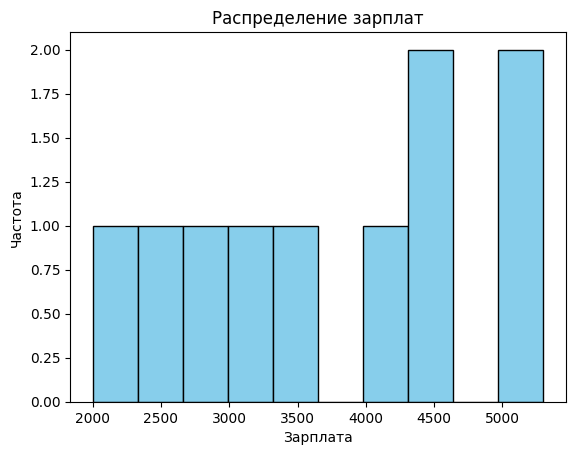

In [83]:
print(f'Среднее: {data['salary'].mean()}')
print(f'Медиана: {data['salary'].median()}')
plt.Figure()
plt.hist(data, color='skyblue', edgecolor='black')
plt.title('Распределение зарплат')
plt.xlabel('Зарплата')
plt.ylabel('Частота')
plt.show()

**3. Оцените вариабельность данных о цене товара**

In [84]:
data = pd.read_csv('/content/data.csv')
data.head(3)

,Price,Value
0,10,2
1,15,25
2,20,3


In [85]:
data_describe = data.describe()
data_describe

,Price,Value
count,20.000000,20.0000
mean,13.600000,14.6000
std,7.666743,11.1185
min,1.000000,2.0000
25%,9.750000,4.0000
50%,14.000000,13.0000
75%,18.250000,25.0000
max,28.000000,35.0000


In [86]:
data.isna().sum()

,0
Price,0
Value,0


In [87]:
data_describe.index.to_list(), data_describe.columns.to_list()

(['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max'],
 ['Price', 'Value'])

In [88]:
mean_price = data_describe.loc['mean', 'Price']
mean_price

np.float64(13.6)

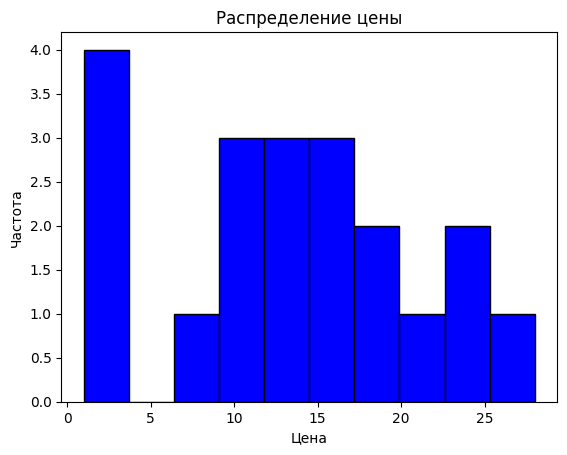

In [89]:
plt.Figure()
plt.hist(data.Price, color='blue', edgecolor='black')
plt.title('Распределение цены')
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.show()

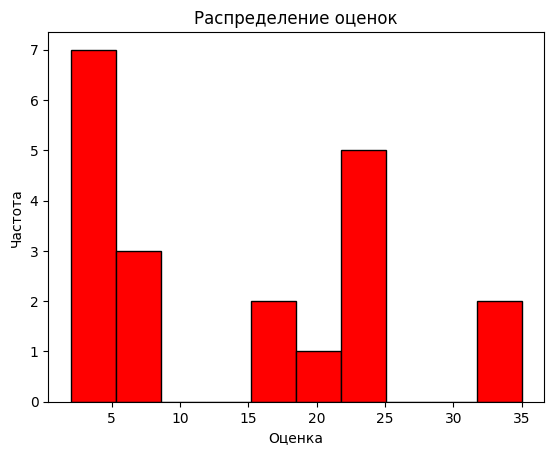

In [90]:
plt.Figure()
plt.hist(data.Value, color='red', edgecolor='black')
plt.title('Распределение оценок')
plt.xlabel('Оценка')
plt.ylabel('Частота')
plt.show()

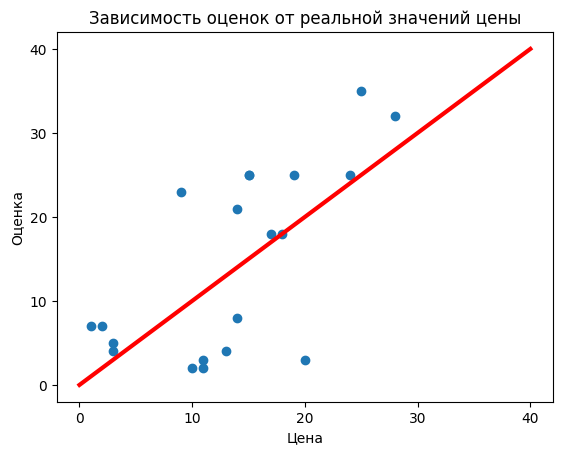

In [91]:
plt.Figure()
plt.scatter(data.Price, data.Value)
plt.title('Зависимость оценок от реальной значений цены')
plt.xlabel('Цена')
plt.xticks(range(0, 41, 10))
plt.ylabel('Оценка')
plt.yticks(range(0, 41, 10))
line = pd.DataFrame({'x' : [0, 40], 'y' : [0, 40]})
plt.plot(line.x, line.y, color='red', linewidth=3)
plt.show()

**Исследуйте распределение данных о клиентах компании**

Анализ данных:
Количество колонок: 1
  Название-variable тип данных-int64
    Количество строк в variable: 49
    Количество пустых значений в variable: 0
    Среднее значение: 21.06
    Стандартное отклонение: 9.58
    Размах: 55.00


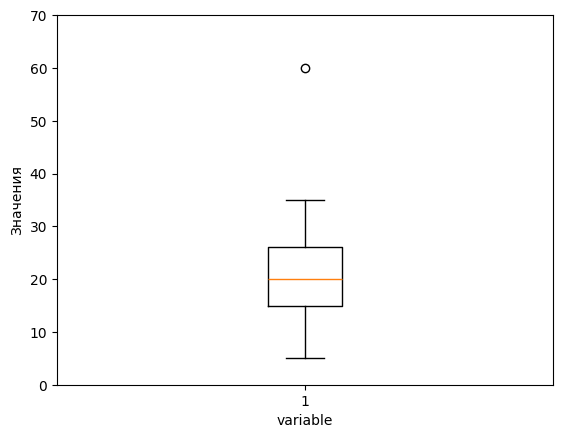

In [92]:
data = pd.read_csv('/content/data_test.csv')
'\033[1m' + 'анализ данных' + '\033[0m'
print('\033[1m' + 'Анализ данных:' + '\033[0m')
print(f'Количество колонок: {data.shape[1]}')
for column in list(data.columns):
  print(f'  Название-{column} тип данных-{data[column].dtype}')
  print(f'    Количество строк в {column}: {data[column].shape[0]}')
  print(f'    Количество пустых значений в {column}: {data[column].isnull().values.sum()}')
  describe = data[column].describe()
  print(f'    Среднее значение: {describe.loc['mean']:.2f}')
  print(f'    Стандартное отклонение: {describe.loc['std']:.2f}')
  print(f'    Размах: {(describe.loc['max'] - describe.loc['min']):.2f}')
  plt.Figure()
  plt.boxplot(data)
  plt.xlabel(column)
  plt.ylabel('Значения')
  plt.yticks(range(0, 71, 10))
  plt.show()


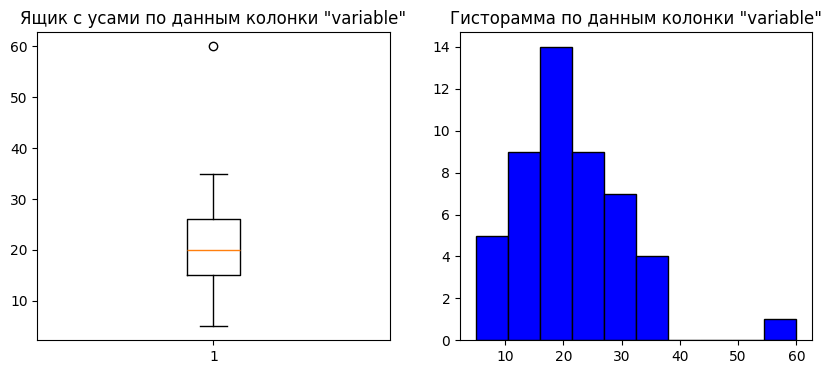

In [93]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.boxplot(data)
ax1.set_title('Ящик с усами по данным колонки "variable"')
ax2.hist(data.variable, color='blue', edgecolor='black')
ax2.set_title('Гисторамма по данным колонки "variable"')
plt.show()

In [96]:
stat, p = shapiro(data.variable)


np.float64(0.0020349954931665527)